In [1]:
#importing the stuff that will be needed for the analysis
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, roc_curve, classification_report)
import matplotlib.pyplot as plt 

In [2]:
dataset_test = pd.read_csv('test.csv')
dataset_training = pd.read_csv('train.csv')

In [3]:
#dropping irrelevant columns
dataset_training = dataset_training.drop(columns = ['Unnamed: 0', 'other']) 
dataset_test  = dataset_test.drop(columns = ['Unnamed: 0', 'other'])

In [4]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [5]:
#set male and female train and testing
male_train   = train_scaled[train_scaled['male'] == 1]
male_test    = test_scaled[test_scaled['male'] == 1]
female_train = train_scaled[train_scaled['female'] == 1]
female_test  = test_scaled[test_scaled['female'] == 1]

print("Male shapes:", male_train.shape, male_test.shape)
print("Female shapes:", female_train.shape, female_test.shape)

Male shapes: (31881, 15) (8071, 15)
Female shapes: (44994, 15) (11148, 15)


In [6]:
drop_cols2 = ['diabetes', 'male', 'female', 'HbA1c_level', 'not current', 'ever', 'never', 'current', 'former', 'no info']

X_male_train = male_train.drop(columns=drop_cols2, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols2, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols2, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols2, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10171    88]
 [  530   359]]

                                0
Accuracy                 0.944564
Sensitivity              0.403825
Specificity              0.991422
AUC-ROC                  0.910092
Precision (No Diabetes)  0.950472
F1-Score (No Diabetes)   0.970515
Precision (Diabetes)     0.803132
F1-Score (Diabetes)      0.537425

              precision    recall  f1-score   support

 No Diabetes      0.950     0.991     0.971     10259
Yes Diabetes      0.803     0.404     0.537       889

    accuracy                          0.945     11148
   macro avg      0.877     0.698     0.754     11148
weighted avg      0.939     0.945     0.936     11148



Males:
Confusion Matrix:
[[7151   91]
 [ 486  343]]


                                0
Accuracy                 0.928509
Sensitivity              0.413752
Specificity              0.987434
AUC-ROC                  0.899887
Precision (No Diabetes)  0.936362
F1-Score (No Diabetes)   0.961221
Precision (Diabetes)     0.790323
F1-Score (Diabetes)      0.543151

              precision    recall  f1-score   support

 No Diabetes      0.936     0.987     0.961      7242
Yes Diabetes      0.790     0.414     0.543       829

    accuracy                          0.929      8071
   macro avg      0.863     0.701     0.752      8071
weighted avg      0.921     0.929     0.918      8071



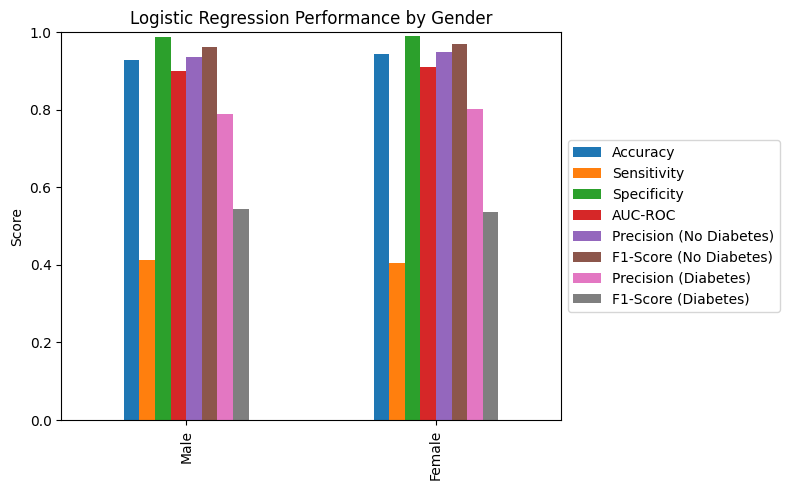

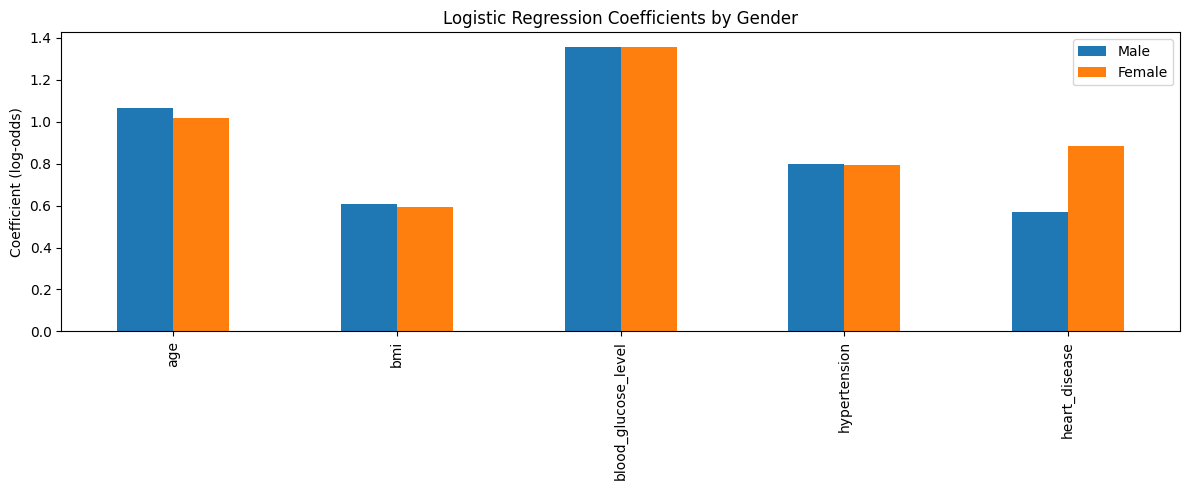

In [7]:
#metrics for males
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

###################################################################################

In [8]:
drop_cols1 = ['diabetes', 'male', 'female', 'hypertension', 'not current', 'ever', 'never', 'current', 'former', 'no info']

X_male_train = male_train.drop(columns=drop_cols1, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols1, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols1, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols1, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10194    65]
 [  328   561]]

                                0
Accuracy                 0.964747
Sensitivity              0.631046
Specificity              0.993664
AUC-ROC                  0.962894
Precision (No Diabetes)  0.968827
F1-Score (No Diabetes)   0.981088
Precision (Diabetes)     0.896166
F1-Score (Diabetes)      0.740594

              precision    recall  f1-score   support

 No Diabetes      0.969     0.994     0.981     10259
Yes Diabetes      0.896     0.631     0.741       889

    accuracy                          0.965     11148
   macro avg      0.932     0.812     0.861     11148
weighted avg      0.963     0.965     0.962     11148



Males:
Confusion Matrix:
[[7149   93]
 [ 296  533]]


                                0
Accuracy                 0.951803
Sensitivity              0.642943
Specificity              0.987158
AUC-ROC                  0.959251
Precision (No Diabetes)  0.960242
F1-Score (No Diabetes)   0.973514
Precision (Diabetes)     0.851438
F1-Score (Diabetes)      0.732646

              precision    recall  f1-score   support

 No Diabetes      0.960     0.987     0.974      7242
Yes Diabetes      0.851     0.643     0.733       829

    accuracy                          0.952      8071
   macro avg      0.906     0.815     0.853      8071
weighted avg      0.949     0.952     0.949      8071



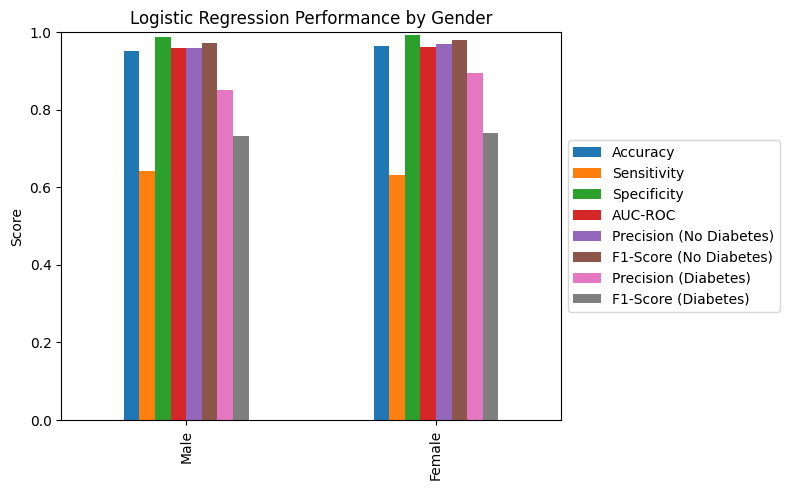

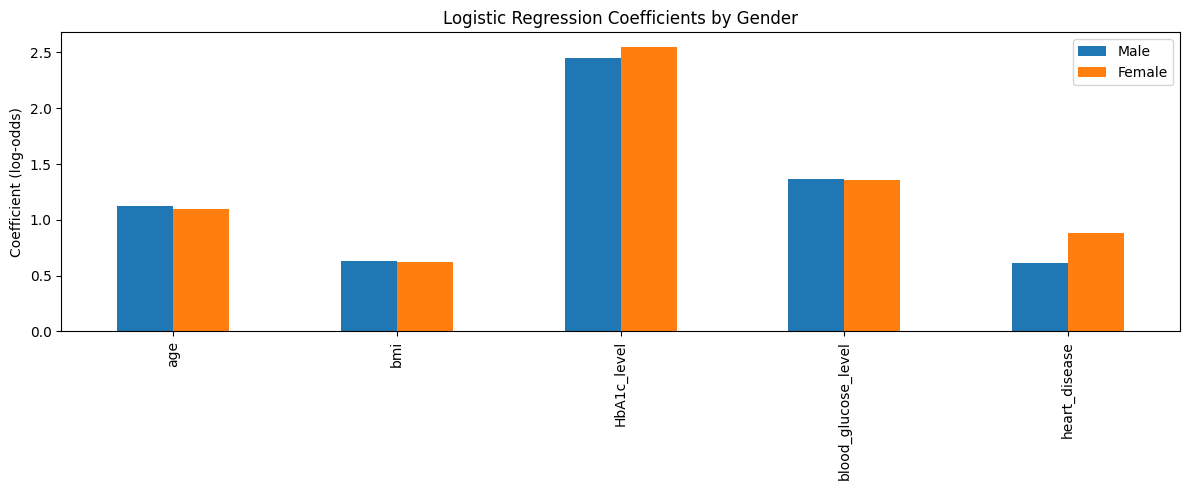

In [9]:
#metrics for males
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

###################################################################################

In [10]:
#drop columns that we will not use for the analysis
drop_cols = ['diabetes', 'male', 'female', 'hypertension']
# drop_cols = ['diabetes', 'male', 'female', 'HbA1c_level']

X_male_train = male_train.drop(columns=drop_cols, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10188    71]
 [  326   563]]

                                0
Accuracy                 0.964388
Sensitivity              0.633296
Specificity              0.993079
AUC-ROC                  0.963686
Precision (No Diabetes)  0.968994
F1-Score (No Diabetes)   0.980889
Precision (Diabetes)     0.888013
F1-Score (Diabetes)      0.739330

              precision    recall  f1-score   support

 No Diabetes      0.969     0.993     0.981     10259
Yes Diabetes      0.888     0.633     0.739       889

    accuracy                          0.964     11148
   macro avg      0.929     0.813     0.860     11148
weighted avg      0.963     0.964     0.962     11148



Males:
Confusion Matrix:
[[7160   82]
 [ 294  535]]


                                0
Accuracy                 0.953413
Sensitivity              0.645356
Specificity              0.988677
AUC-ROC                  0.959698
Precision (No Diabetes)  0.960558
F1-Score (No Diabetes)   0.974415
Precision (Diabetes)     0.867099
F1-Score (Diabetes)      0.739972

              precision    recall  f1-score   support

 No Diabetes      0.961     0.989     0.974      7242
Yes Diabetes      0.867     0.645     0.740       829

    accuracy                          0.953      8071
   macro avg      0.914     0.817     0.857      8071
weighted avg      0.951     0.953     0.950      8071



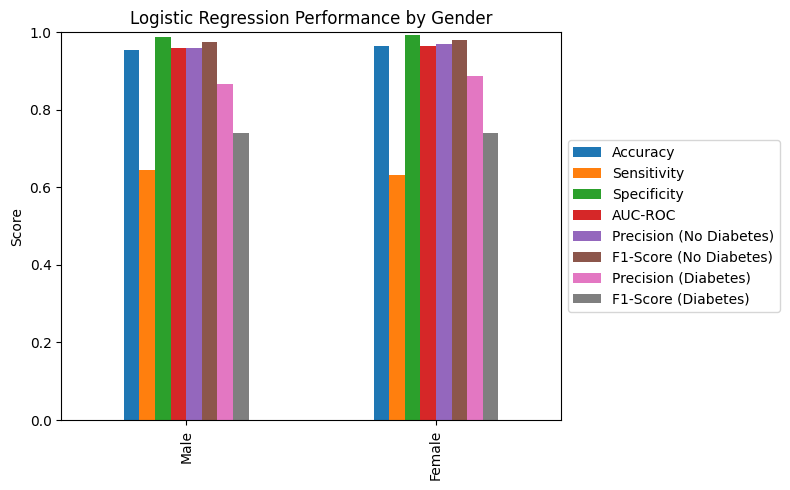

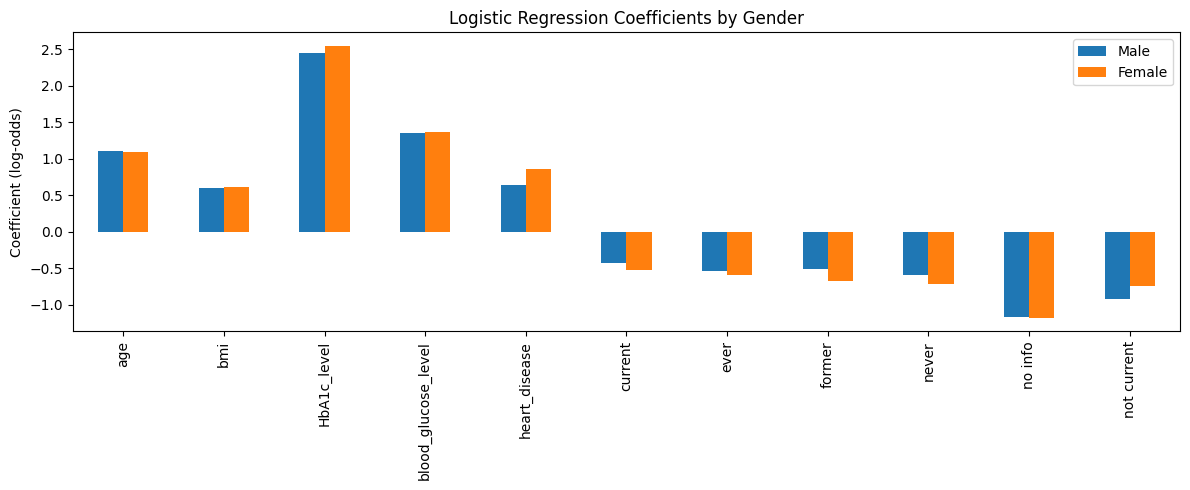

In [11]:
#metrics for males
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

###########################################################

In [12]:
#drop columns that we will not use for the analysis
drop_cols = ['diabetes', 'male', 'female', 'HbA1c_level']

X_male_train = male_train.drop(columns=drop_cols, axis = 1)
y_male_train = male_train['diabetes']
X_male_test  = male_test.drop(columns=drop_cols, axis = 1)
y_male_test  = male_test['diabetes']

X_female_train = female_train.drop(columns=drop_cols, axis = 1)
y_female_train = female_train['diabetes']
X_female_test  = female_test.drop(columns=drop_cols, axis = 1)
y_female_test  = female_test['diabetes']

#logisitc regression function
lr_male   = LogisticRegression()
lr_female = LogisticRegression()

lr_male.fit(X_male_train, y_male_train)
lr_female.fit(X_female_train, y_female_train)

#metrics for females
y_pred = lr_female.predict(X_female_test)
y_prob = lr_female.predict_proba(X_female_test)[:,1]

accuracy = accuracy_score(y_female_test, y_pred) 
auc = roc_auc_score(y_female_test, y_prob)
sensitivity = recall_score(y_female_test, y_pred)
cm = confusion_matrix(y_female_test, y_pred)

print("Females:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_female_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_female_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_female_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_female_test, y_pred, pos_label=1)
}

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_female_test, y_pred, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))


Females:
Confusion Matrix:
[[10178    81]
 [  529   360]]

                                0
Accuracy                 0.945282
Sensitivity              0.404949
Specificity              0.992104
AUC-ROC                  0.911838
Precision (No Diabetes)  0.950593
F1-Score (No Diabetes)   0.970905
Precision (Diabetes)     0.816327
F1-Score (Diabetes)      0.541353

              precision    recall  f1-score   support

 No Diabetes      0.951     0.992     0.971     10259
Yes Diabetes      0.816     0.405     0.541       889

    accuracy                          0.945     11148
   macro avg      0.883     0.699     0.756     11148
weighted avg      0.940     0.945     0.937     11148



Males:
Confusion Matrix:
[[7162   80]
 [ 480  349]]


                                0
Accuracy                 0.930616
Sensitivity              0.420989
Specificity              0.988953
AUC-ROC                  0.901739
Precision (No Diabetes)  0.937189
F1-Score (No Diabetes)   0.962376
Precision (Diabetes)     0.813520
F1-Score (Diabetes)      0.554849

              precision    recall  f1-score   support

 No Diabetes      0.937     0.989     0.962      7242
Yes Diabetes      0.814     0.421     0.555       829

    accuracy                          0.931      8071
   macro avg      0.875     0.705     0.759      8071
weighted avg      0.924     0.931     0.921      8071



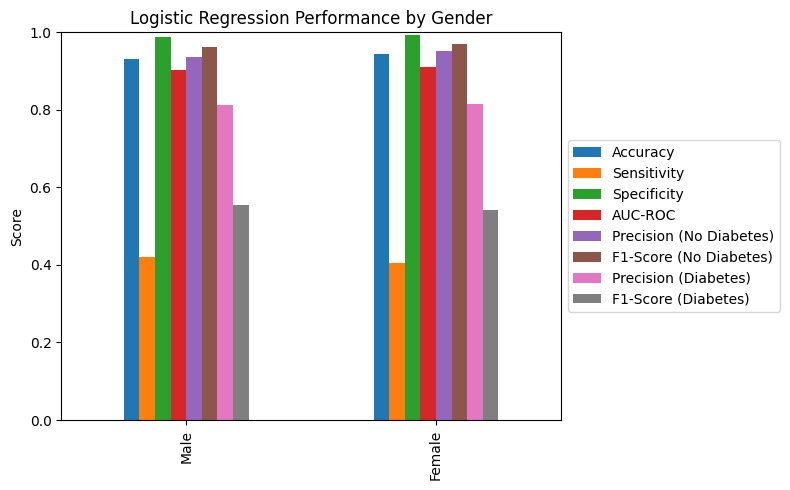

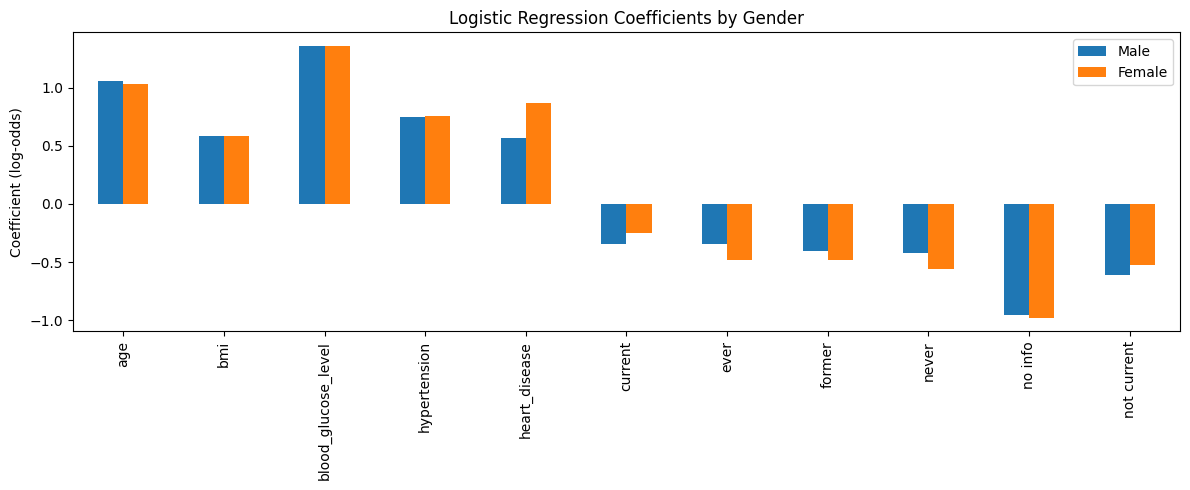

In [13]:
#metrics for males
y_pred2 = lr_male.predict(X_male_test)
y_prob2 = lr_male.predict_proba(X_male_test)[:,1]

accuracy = accuracy_score(y_male_test, y_pred2) 
auc = roc_auc_score(y_male_test, y_prob2)
sensitivity = recall_score(y_male_test, y_pred2)
cm = confusion_matrix(y_male_test, y_pred2)

print("Males:")

print("Confusion Matrix:")
print(cm)
print()

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) 

metrics_summary2 = {
    'Accuracy': accuracy,
    'Sensitivity': sensitivity,   
    'Specificity': specificity,   
    'AUC-ROC': auc,
    'Precision (No Diabetes)': precision_score(y_male_test, y_pred2, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_male_test, y_pred2, pos_label=0),
    'Precision (Diabetes)': precision_score(y_male_test, y_pred2, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_male_test, y_pred2, pos_label=1)
}

print()

metrics_df2 = pd.DataFrame([metrics_summary2])
print(metrics_df2.T)
print()

print(classification_report(y_male_test, y_pred2, digits=3, target_names=['No Diabetes', 'Yes Diabetes']))

#coefficients
coef_male   = pd.Series(lr_male.coef_[0], index=X_male_train.columns, name='Male')
coef_female = pd.Series(lr_female.coef_[0], index=X_female_train.columns, name='Female')

coef_compare = pd.concat([coef_male, coef_female], axis=1)
coef_compare.sort_values(by=['Male','Female'], key=abs, ascending=False)

metrics_df3 = pd.concat([metrics_df2, metrics_df], axis=0)
metrics_df3.index = ['Male', 'Female']

#plots
ax = metrics_df3.plot.bar(figsize=(8,5))
ax.set_title("Logistic Regression Performance by Gender")
ax.set_ylim(0,1)
ax.set_ylabel("Score")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

coef_compare[['Male','Female']].plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients by Gender")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show() 